In [1]:
import os.path
import traceback
import zipfile

import pyreadstat
import seaborn as sns
from pandas import DataFrame

from util.download_util import download_files
from util.dta_file_utils import find_dta_file

In [2]:
sns.set_palette("muted")

In [3]:
STATA_BASE_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata/"
DOC_BASE_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/"
DATA_BASE_PATH = "data"
DOC_BASE_PATH = "doc"
os.makedirs(DATA_BASE_PATH, exist_ok=True)
os.makedirs(DOC_BASE_PATH, exist_ok=True)

In [4]:
urls = []
pdf_urls = []
years = ["2022"]
stata_zip_file_names = []
pdf_file_names = []
for year in years:
    file_name = f"ED{year}-stata.zip"
    yy = year[-2:]
    pdf_file_name = f"doc{yy}-ed-508.pdf"
    pdf_url = DOC_BASE_URL + pdf_file_name
    pdf_urls.append(pdf_url)
    pdf_file_names.append(os.path.join(DOC_BASE_PATH, pdf_file_name))
    url = STATA_BASE_URL + file_name
    urls.append(url)
    stata_zip_file_names.append(os.path.join(DATA_BASE_PATH, file_name))

In [5]:
await download_files(urls, stata_zip_file_names)
await download_files(pdf_urls, pdf_file_names)

data\ED2022-stata.zip: 100%|██████████| 2.31M/2.31M [00:01<00:00, 2.05MB/s]
doc\doc22-ed-508.pdf: 100%|██████████| 2.65M/2.65M [00:01<00:00, 2.23MB/s]


In [6]:
df: DataFrame = None
meta = None
for file_name in stata_zip_file_names:
    with zipfile.ZipFile(file_name, "r") as z:
        for stata_file in find_dta_file(z.namelist()):
            print(stata_file)
            with z.open(stata_file) as f:
                try:
                    df, meta = pyreadstat.read_dta(f)
                except Exception as e:
                    print("Could not read stata file:", stata_file)
                    traceback.print_exc()



ed2022-stata.dta


In [7]:
for col in df.columns:
    print(col)

VMONTH
VDAYR
ARRTIME
WAITTIME
LOV
AGE
AGER
AGEDAYS
RESIDNCE
SEX
ETHUN
ETHIM
RACEUN
RACER
RACERETH
ARREMS
AMBTRANSFER
NOPAY
PAYPRIV
PAYMCARE
PAYMCAID
PAYWKCMP
PAYSELF
PAYNOCHG
PAYOTH
PAYDK
PAYTYPER
TEMPF
PULSE
RESPR
BPSYS
BPDIAS
POPCT
IMMEDR
PAINSCALE
SEEN72
RFV1
RFV2
RFV3
RFV4
RFV5
RFV13D
RFV23D
RFV33D
RFV43D
RFV53D
EPISODE
INJURY
INJPOISAD
INJURY72
INTENT15
INJURY_ENC
CAUSE1
CAUSE2
CAUSE3
DIAG1
DIAG2
DIAG3
DIAG4
DIAG5
PRDIAG1
PRDIAG2
PRDIAG3
PRDIAG4
PRDIAG5
ETOHAB
ALZHD
ASTHMA
CANCER
CEBVD
CKD
COPD
CHF
CAD
DEPRN
DIABTYP1
DIABTYP2
DIABTYP0
ESRD
HPE
EDHIV
HYPLIPID
HTN
OBESITY
OSA
OSTPRSIS
SUBSTAB
NOCHRON
TOTCHRON
DIAGSCRN
ABG
BAC
BMP
BNP
BUNCREAT
CARDENZ
CBC
CMP
BLOODCX
TRTCX
URINECX
WOUNDCX
OTHCX
DDIMER
ELECTROL
GLUCOSE
LACTATE
LFT
PTTINR
OTHERBLD
CARDMON
EKG
HIVTEST
FLUTEST
PREGTEST
TOXSCREN
URINE
OTHRTEST
ANYIMAGE
XRAY
CATSCAN
CTCONTRAST
CTAB
CTCHEST
CTHEAD
CTOTHER
CTUNK
MRI
MRICONTRAST
ULTRASND
OTHIMAGE
COVIDTEST
COVIDANTIBODY
TOTDIAG
PROC
BPAP
BLADCATH
CASTSPLINT
CENTLINE
CPR
ENDOI

In [8]:
print(len(df.columns))

913


## Initial Assessment of the 2022 NHAMCS ED Variables
1. **Description of Data** - Each record represents one sampled ED visit
2. **Number of Columns** - 913 (High dimensional)

## Next Steps
We need to first understand what variables are needed before triage. Additionally after predicting triage acuity. After predicting the triage acuity we can predict the safest wait time possible.

## Descriptive Variables
1. SEX - Gender of the patient
   1. 1 = Female
   2. 2 = Male
## Variables needed during Triage
1. IMMEDR (TARGET) - Immediacy with which patient should be seen.
   1. Key codes:
      1. 1 = Immediate
      2. 2 = Emergent
      3. 3 = Urgent
      4. 4 = Semi-urgent
      5. 0 = "No triage" but Emergency Service Area (ESA) of the hospital conducts nursing triage
      6. 7 = ESA does not conduct nursing triage
      7. -8 = Unknown; -9 = Blank


In [9]:
df["IMMEDR"].value_counts()

IMMEDR
 3    5340
-8    3788
 4    2826
 2    1595
 7    1079
 0     587
-9     364
 5     307
 1     139
Name: count, dtype: int64

In [10]:
df["IMMEDR"].describe()

count    16025.000000
mean         0.384462
std          5.179554
min         -9.000000
25%         -8.000000
50%          3.000000
75%          4.000000
max          7.000000
Name: IMMEDR, dtype: float64

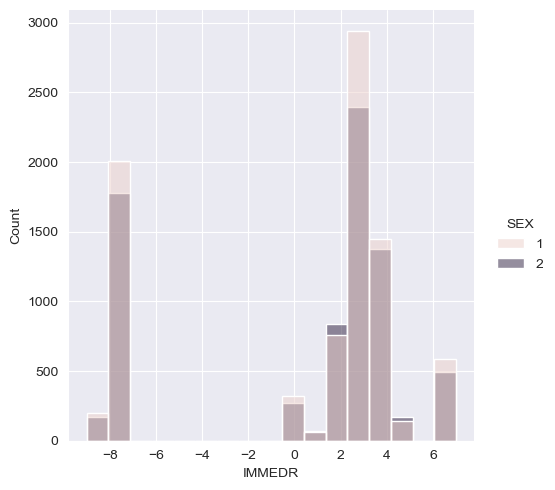

In [11]:
sns.displot(df, x="IMMEDR", hue="SEX")

In [12]:
df.groupby("SEX")["IMMEDR"].describe()

,count,mean,std,min,25%,50%,75%,max
SEX,,,,,,,,
1,8465.0,0.377673,5.191894,-9.0,-8.0,3.0,4.0,7.0
2,7560.0,0.392063,5.166034,-9.0,-8.0,3.0,4.0,7.0


<Axes: xlabel='VMONTH', ylabel='IMMEDR'>

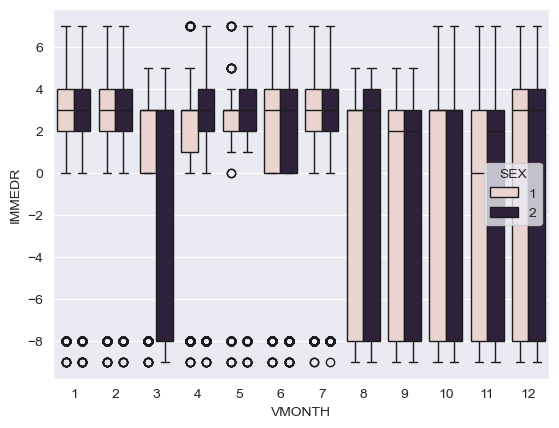

In [13]:
sns.boxplot(x="VMONTH", y="IMMEDR", data=df,hue="SEX")

In [14]:
df.groupby("VMONTH")["IMMEDR"].describe()

,count,mean,std,min,25%,50%,75%,max
VMONTH,,,,,,,,
1,1468.0,2.025886,4.346842,-9.0,2.0,3.0,4.0,7.0
2,1619.0,1.711550,4.266631,-9.0,2.0,3.0,4.0,7.0
3,1388.0,-0.125360,5.069537,-9.0,-8.0,3.0,3.0,5.0
4,1367.0,0.527432,4.913954,-9.0,1.0,3.0,3.0,7.0
5,1135.0,1.614978,3.956860,-9.0,2.0,3.0,4.0,7.0
6,1408.0,0.949574,5.097446,-9.0,0.0,3.0,4.0,7.0
7,1448.0,1.345304,4.977444,-9.0,2.0,3.0,4.0,7.0
8,1293.0,-1.119876,5.608652,-9.0,-8.0,3.0,3.0,5.0
9,763.0,-1.216252,5.420545,-9.0,-8.0,2.0,3.0,5.0


<Axes: xlabel='VMONTH', ylabel='IMMEDR'>

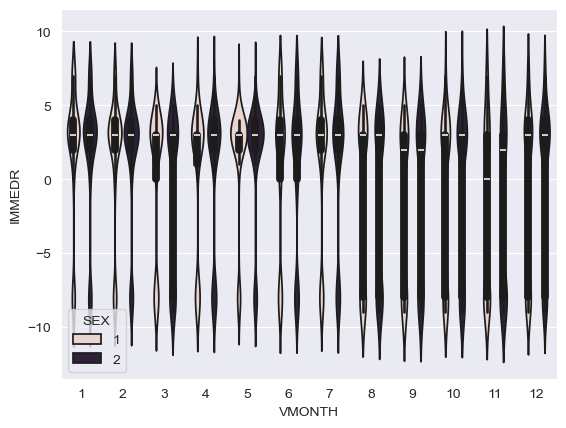

In [15]:
sns.violinplot(x="VMONTH", y="IMMEDR", data=df,hue="SEX")